# Bending a plate with a reference point
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meyer-nils/torch-fem/blob/main/examples/basic/assembly/planar_rp.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/meyer-nils/torch-fem/main?labpath=examples/basic/assembly/planar_rp.ipynb)

A plate clamped at one end and rotated at the other by a `ReferencePoint`. In two
dimensions the point carries two translations and one rotation, which is how a
rotation reaches a mesh whose nodes carry translations only.

In [ ]:
import torch

from torchfem import Assembly, Planar, ReferencePoint
from torchfem.materials import IsotropicElasticityPlaneStress
from torchfem.mesh import rect_quad

torch.set_default_dtype(torch.float64)

# Material properties
material = IsotropicElasticityPlaneStress(1000.0, 0.3)

In [ ]:
# Geometry and mesh
length = 5.0
height = 1.0
angle = 0.2
nodes, elements = rect_quad(21, 5, length, height)
left = nodes[:, 0] == 0.0
right = nodes[:, 0] == length

# Planar model
plate = Planar(nodes, elements, material)
plate.constraints[left] = True

# Reference point
hub = ReferencePoint([length + 1.0, height / 2])
hub.constraints[0, 2] = True
hub.displacements[0, 2] = angle

## Assembly

The tip nodes are the secondary side and follow the rigid-body motion of the
point. Only its rotation is prescribed, so the translations stay free, the plate
ends in pure bending, and the moment that takes is the reaction at the point.

In [ ]:
assembly = Assembly([plate, hub])
assembly.coupling(plate, right, hub)

u, f, sigma, _, _ = assembly.solve()

print(f"Reaction moment: {f[1][0, 2]:.4f}")

Reaction moment: 3.4463


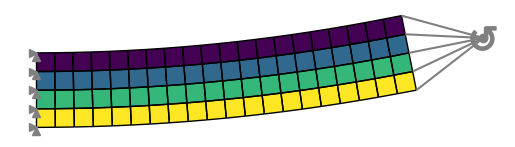

In [ ]:
# One field per part, so the reference point gets None
assembly.plot(u=u, element_property=[sigma[0][:, 0, 0], None], bcs=True)